The contents of this notebook were created with assistance from Claude and Gemini generative AI.

# ModernBERT token-ablation — word-level, target-only (single-word necessity)

Companion to `stance_evaluation_toolkit.ipynb`. That notebook gives the **attribution** side
(Integrated-Gradients: what the model *leans on*); this one gives the **necessity** side: mask each
candidate **word** in the documents that contain it and measure how the prediction moves.

**Scope / method (by design):**
- **Corpus** = the `ABLATION_CORPUS` flag: **`"pool"`** (the ~4.8k-doc attribution corpus, uniform
  weight — many occurrences per word ⇒ tight CIs, matches the attribution) or **`"gold"`** (301
  human-gold items, population-weighted with `w`). Necessity is a property of the *model*, not of
  labels, so the pool is a valid — and better-powered — corpus.
- **Word-level masking.** Candidate words are matched via the fast tokenizer's `word_ids()` + offset
  mapping, and **all subword tokens of a word** are replaced with `[MASK]` (ModernBERT is
  MLM-pretrained, so `[MASK]` is the natural counterfactual), keeping length and positions fixed.
- **TARGET span only.** Only words inside the `[TARGET]` region are considered/masked — `[CONTEXT]`
  is scaffolding, not the classified unit. Matches the target-only attribution.
- **Candidates** come from notebook 1's **target-only** attribution
  (`mbert_tokens_<class>_target.csv`); top `TOP_FOR` for-words and `TOP_AGAINST` against-words/class.

**Metrics (per word, on the docs that contain it):** `Δ class-logit` (primary, pre-softmax),
`Δ P(class)`, decision-flip rate, **faithful?** (does the sign of `Δlogit` oppose the attribution
sign), and **excess vs. a frequency-matched random-word baseline**.

**Caveats:** single-word masking underestimates redundant signals; rare words / small classes give
wide CIs — read the intervals. Outputs are suffixed `_<corpus>` so pool/gold runs don't overwrite.
**Kernel: `mads-m2-eval`.**

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

P15 = Path.cwd()
if str(P15) not in sys.path:
    sys.path.insert(0, str(P15))
import m5_common as m5            # shared data prep + tuned-model paths (single source of truth)

## 1. Config
Absolute paths (cloud-drive safe). Candidate words = notebook 1's target-only attribution.

In [2]:
import os

# labels (4-class stance; "off-topic" is the off-axis NA class)
CLASS_ORDER     = list(m5.LABELS)          # ["anti", "neutral", "pro", "off-topic"]
ONTOPIC_CLASSES = list(m5.ON_TOPIC)        # ["anti", "neutral", "pro"]

# corpus to measure necessity on
ABLATION_CORPUS = "pool"   # "pool" (~4.8k docs, uniform weight, matches attribution) or "gold" (301, weighted)
OUT_SUFFIX      = f"_{ABLATION_CORPUS}"     # appended to every output file so pool/gold don't overwrite

# paths — ABSOLUTE (the G: cloud drive raises WinError 433 on relative paths)
EVAL_DIR       = Path.cwd()
NB1_TOKENS_DIR = EVAL_DIR / "outputs"                          # where notebook 1 wrote attribution CSVs
CAND_TAG       = "_target"                                     # use the target-only (512-cap) attribution
OUTPUT_DIR     = str(EVAL_DIR / "outputs_token_ablation")      # this notebook's figures + results
os.makedirs(OUTPUT_DIR, exist_ok=True)
def out(name):
    return os.path.join(OUTPUT_DIR, name)

# masking / candidates
MAX_LEN      = 512        # tuned ModernBERT deployment window (left-truncation keeps the TARGET)
TARGET_ONLY  = True       # consider/mask only words in the [TARGET] span
TOP_FOR      = 4          # ablate the top-N for-words per class   (mean_attr > 0)
TOP_AGAINST  = 4          # ablate the top-N against-words per class (mean_attr < 0)
MIN_DOC_FREQ = 5          # skip words occurring in fewer than this many TARGET spans (pool gives plenty)

# bootstrap / baselines
N_BOOTSTRAP         = 5000
SEED                = m5.SEED          # 42
RUN_RANDOM_BASELINE = True             # frequency-matched random-word control
N_RANDOM_DRAWS      = 2

# ── colours (coastal palette; salmon = supports class, teal = opposes) ──────────
FOR_COLOR     = "#E29578"   # masking DROPS the class logit -> the word supports the class
AGAINST_COLOR = "#006D77"   # masking RAISES the class logit -> the word opposes the class
FAITHFUL_WASH = "#83C5BE"   # light-teal shade for the sign-consistent (faithful) quadrants
EDGE          = "#3a3a3a"   # thin marker edge so the pale class colours stay visible
# off-topic is a DIFFERENT axis (not on the for/against spectrum) -> deep plum, off-palette on purpose
_CLASS_COLORS = {"anti": "#E29578", "neutral": "#9DCEDF", "pro": "#006D77", "off-topic": "#5A3E54"}

print("classes:", CLASS_ORDER, "| corpus:", ABLATION_CORPUS)
print("candidates from:", NB1_TOKENS_DIR, "| tag:", CAND_TAG, "| target_only:", TARGET_ONLY)
print("outputs ->", OUTPUT_DIR, "| suffix:", OUT_SUFFIX)

classes: ['anti', 'neutral', 'pro', 'off-topic'] | corpus: pool
candidates from: outputs | tag: _target | target_only: True
outputs -> outputs_token_ablation | suffix: _pool


## 2. Loaders

In [3]:
def load_modernbert():
    """Tuned ModernBERT (best 5-fold CV) + tokenizer, on GPU in eval mode (left-truncation)."""
    import json, torch  # noqa: F401
    from transformers import AutoTokenizer, AutoModelForSequenceClassification
    p = m5.model_path("tuned", "ModernBERT")
    cfg = json.loads((p / "inference_config.json").read_text())
    tok = AutoTokenizer.from_pretrained(p)
    tok.truncation_side = cfg.get("truncation_side", "left")   # keep the TARGET (end) on truncation
    model = AutoModelForSequenceClassification.from_pretrained(p).to("cuda").eval()
    return model, tok


def load_corpus():
    """Documents to measure necessity on, per ABLATION_CORPUS.
    'pool' = the ~4.8k attribution corpus (uniform weight); 'gold' = 301 human items (pop weight w)."""
    if ABLATION_CORPUS == "pool":
        d = m5.load_frames()["df"].reset_index(drop=True)[["text", "label"]].copy()
        d["w"] = 1.0
        return d
    g = m5.load_frames()["gold_text"].reset_index(drop=True)
    return g[["text", "label", "w"]].copy()

## 3. Candidate words
Read the **target-only** per-class attribution CSVs from notebook 1 and keep the top for/against words.

In [4]:
def load_candidate_tokens():
    """Per-class candidate words from notebook 1's target-only attribution CSVs."""
    tables = {}
    for c in CLASS_ORDER:
        f = NB1_TOKENS_DIR / f"mbert_tokens_{c}{CAND_TAG}.csv"
        if not f.exists():
            raise FileNotFoundError(
                f"missing candidate file: {f}\n"
                "Run notebook 1's target-only attribution + write_token_csvs first.")
        tables[c] = pd.read_csv(f)
    print("candidate rows per class:", {c: len(tables[c]) for c in CLASS_ORDER})
    return tables


def select_candidates(tok_tables):
    """-> DataFrame[class, token, mean_attr, direction] of the words to ablate."""
    rows = []
    for c in CLASS_ORDER:
        df = tok_tables.get(c)
        if df is None or df.empty:
            continue
        pos = df[df["mean_attr"] > 0].sort_values("mean_attr", ascending=False).head(TOP_FOR)
        neg = df[df["mean_attr"] < 0].sort_values("mean_attr").head(TOP_AGAINST)
        for _, r in pd.concat([pos, neg]).iterrows():
            rows.append(dict(**{"class": c}, token=str(r["token"]), mean_attr=float(r["mean_attr"]),
                             direction=("for" if r["mean_attr"] > 0 else "against")))
    return pd.DataFrame(rows)

## 4. Tokenize gold (word-level, target-only) + forward core
`tokenize_gold` builds, per gold doc, a **word → [token positions]** map restricted to the TARGET
span. Words are read from the original text via offset mapping (whole words, not subword fragments);
all subword positions of a word are grouped so masking removes the entire word.

In [5]:
import torch
from collections import defaultdict
from transformers import DataCollatorWithPadding


def _softmax(z):
    z = z - z.max(axis=1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)


def forward_logits(model, tok, list_input_ids, bs=64):
    """Logits (n, n_classes) for a list of (already-tokenized) input-id sequences (bf16 autocast)."""
    coll = DataCollatorWithPadding(tok)
    outs = []
    with torch.no_grad():
        for i in range(0, len(list_input_ids), bs):
            b = coll([{"input_ids": list(ii)} for ii in list_input_ids[i:i + bs]])
            b = {k: v.to(model.device) for k, v in b.items()}
            with torch.autocast("cuda", dtype=torch.bfloat16):
                outs.append(model(**b).logits.float().cpu())
    return torch.cat(outs).numpy()


def tokenize_gold(tok, texts):
    """Per-doc input-ids + a WORD -> [token positions] map, restricted to the TARGET span.

    Words come from the ORIGINAL text via offset mapping; a word's positions are all the subword
    token positions that compose it (so masking removes the whole word). Markers and pure-punctuation
    are dropped. Returns (ids_list, pos_maps, specials)."""
    assert tok.is_fast, "need a fast tokenizer for word_ids()/offset_mapping"
    texts = list(texts)
    enc = tok(texts, truncation=True, max_length=MAX_LEN, return_offsets_mapping=True)
    ids_list = enc["input_ids"]
    specials = set(tok.all_special_ids)
    markers = ("[CONTEXT]", "[TARGET]", "[OP]")
    pos_maps = []
    for di, ids in enumerate(ids_list):
        text = texts[di]
        wids = enc.word_ids(di)
        offs = enc["offset_mapping"][di]
        tgt_start = text.find("[TARGET]") if TARGET_ONLY else -1
        mspans = []
        for mk in markers:
            p = text.find(mk)
            while p != -1:
                mspans.append((p, p + len(mk))); p = text.find(mk, p + 1)
        in_marker = lambda s, e: any(s < me and ms < e for ms, me in mspans)

        by_wid = {}                                   # wid -> [positions, min_s, max_e]
        for p, (i, wid, (s, e)) in enumerate(zip(ids, wids, offs)):
            if i in specials or wid is None or e <= s:
                continue
            if wid not in by_wid:
                by_wid[wid] = [[], s, e]
            by_wid[wid][0].append(p)
            by_wid[wid][1] = min(by_wid[wid][1], s)
            by_wid[wid][2] = max(by_wid[wid][2], e)

        m = defaultdict(list)
        for wid, (positions, s, e) in by_wid.items():
            if (tgt_start != -1 and s < tgt_start) or in_marker(s, e):
                continue
            word = text[s:e].strip().lower()
            if word and any(ch.isalnum() for ch in word):
                m[word].extend(positions)             # all subword positions of this word
        pos_maps.append(m)
    return ids_list, pos_maps, specials

<home>\.venvs\mads-m2-eval\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Run
## 5. Setup — model, corpus, baseline logits, candidates

In [6]:
model, tok = load_modernbert()
MASK_ID = tok.mask_token_id
assert MASK_ID is not None, "tokenizer has no [MASK] token"

data  = load_corpus()
y_doc = data["label"].to_numpy(dtype=object)
w_doc = data["w"].to_numpy(dtype=float)

doc_ids, pos_maps, SPECIALS = tokenize_gold(tok, data["text"])
tok_docs = defaultdict(list)                       # word -> [doc indices] (TARGET span)
for di, pm in enumerate(pos_maps):
    for w in pm:
        tok_docs[w].append(di)

orig_logits = forward_logits(model, tok, doc_ids)
orig_prob   = _softmax(orig_logits)
orig_argmax = orig_logits.argmax(1)
acc = float((np.array([CLASS_ORDER[i] for i in orig_argmax], dtype=object) == y_doc).mean())
print(f"corpus={ABLATION_CORPUS}: {len(data)} docs | baseline acc {acc:.3f} "
      f"| distinct target words {len(tok_docs)}")

tok_tables = load_candidate_tokens()
cands = select_candidates(tok_tables)
print("words to ablate:", len(cands))

Loading weights: 100%|██████████| 138/138 [00:00<00:00, 2967.07it/s]


corpus=pool: 4830 docs | baseline acc 0.998 | distinct target words 14054
candidate rows per class: {'anti': 40, 'neutral': 40, 'pro': 40, 'off-topic': 40}
words to ablate: 32


### Ablation engine
For each candidate word: mask all its TARGET-span occurrences in the gold docs that contain it,
re-score, and aggregate the population-weighted effect with a bootstrap CI, plus the
frequency-matched random-word baseline.

In [7]:
def _mask_doc(di, positions):
    ids = list(doc_ids[di])
    for p in positions:
        ids[p] = MASK_ID
    return ids


def _wmean(x, w):
    w = np.asarray(w, float)
    return float(np.sum(np.asarray(x, float) * w) / np.sum(w)) if np.sum(w) > 0 else float("nan")


def _boot_ci(x, w, B=N_BOOTSTRAP, seed=SEED):
    x, w = np.asarray(x, float), np.asarray(w, float)
    n = len(x)
    if n == 0:
        return (float("nan"), float("nan"))
    rng = np.random.default_rng(seed)
    pts = np.empty(B)
    idx = np.arange(n)
    for b in range(B):
        ix = rng.choice(idx, n, replace=True)
        pts[b] = _wmean(x[ix], w[ix])
    return tuple(np.percentile(pts, [2.5, 97.5]))


def _random_baseline_dlogit(docs, c_idx, draws=N_RANDOM_DRAWS, seed=SEED):
    """Mask one random non-special token per affected doc; mean Δlogit_c over draws."""
    rng = np.random.default_rng(seed + 1)
    acc = np.zeros(len(docs))
    for _ in range(draws):
        masked = []
        for di in docs:
            ids = list(doc_ids[di])
            elig = [p for p, i in enumerate(ids) if i not in SPECIALS]
            if elig:
                ids[rng.choice(elig)] = MASK_ID
            masked.append(ids)
        ml = forward_logits(model, tok, masked)
        acc += (ml[:, c_idx] - orig_logits[docs, c_idx])
    return acc / draws


def ablate_one(token, c_idx):
    docs = tok_docs.get(token, [])
    n_docs = len(docs)
    n_occ = int(sum(len(pos_maps[di][token]) for di in docs))   # masked subword positions
    if n_docs < MIN_DOC_FREQ:
        return None
    masked = [_mask_doc(di, pos_maps[di][token]) for di in docs]
    ml = forward_logits(model, tok, masked)
    mp = _softmax(ml)
    docs_arr = np.array(docs)
    dlogit = ml[:, c_idx] - orig_logits[docs_arr, c_idx]
    dprob  = mp[:, c_idx] - orig_prob[docs_arr, c_idx]
    flip   = (ml.argmax(1) != orig_argmax[docs_arr])
    w = w_doc[docs_arr]
    lo, hi = _boot_ci(dlogit, w)
    rec = dict(n_docs=n_docs, n_occ=n_occ,
               mean_dlogit=_wmean(dlogit, w), dlogit_lo=lo, dlogit_hi=hi,
               mean_dprob=_wmean(dprob, w), flip_rate=_wmean(flip.astype(float), w))
    if RUN_RANDOM_BASELINE:
        rb = _random_baseline_dlogit(docs, c_idx)
        rec["mean_dlogit_random"] = _wmean(rb, w)
        rec["excess_dlogit"] = rec["mean_dlogit"] - rec["mean_dlogit_random"]
    return rec


def run_ablation(cands):
    rows = []
    for _, r in cands.iterrows():
        c = r["class"]; c_idx = CLASS_ORDER.index(c)
        rec = ablate_one(r["token"], c_idx)
        if rec is None:
            continue
        # faithful: removing a for-word (attr>0) should drop the logit (dlogit<0), and vice versa
        faithful = (np.sign(rec["mean_dlogit"]) == -np.sign(r["mean_attr"])) and rec["mean_dlogit"] != 0
        rows.append(dict(**{"class": c}, token=r["token"], direction=r["direction"],
                         mean_attr=r["mean_attr"], faithful=bool(faithful), **rec))
    df = pd.DataFrame(rows)
    return df.sort_values(["class", "mean_attr"], ascending=[True, False]).reset_index(drop=True)

### Run the ablation

In [8]:
results = run_ablation(cands)
results.to_csv(out(f"token_ablation_results{OUT_SUFFIX}.csv"), index=False)
print("faithful words: %d / %d (%.0f%%)" % (
    results["faithful"].sum(), len(results), 100 * results["faithful"].mean()))
cols = ["class", "token", "direction", "mean_attr", "n_docs", "n_occ",
        "mean_dlogit", "dlogit_lo", "dlogit_hi", "mean_dprob", "flip_rate"]
if RUN_RANDOM_BASELINE:
    cols += ["mean_dlogit_random", "excess_dlogit"]
results[cols].round(3)

faithful words: 20 / 32 (62%)


,class,token,direction,mean_attr,n_docs,n_occ,mean_dlogit,dlogit_lo,dlogit_hi,mean_dprob,flip_rate,mean_dlogit_random,excess_dlogit
0,anti,hurts,for,0.234,20,22,0.185,-0.504,0.881,-0.042,0.050,-0.012,0.196
1,anti,nonsense,for,0.216,20,20,-0.225,-1.031,0.530,0.004,0.100,0.043,-0.268
2,anti,scam,for,0.208,20,27,-3.193,-4.883,-1.648,-0.151,0.150,-0.563,-2.630
3,anti,awful,for,0.208,17,19,-0.843,-1.595,-0.198,-0.006,0.000,-0.301,-0.542
4,anti,surprised,against,-0.050,28,34,0.123,-0.402,0.734,0.020,0.071,0.091,0.032
5,anti,security,against,-0.061,11,12,0.315,-0.130,0.709,-0.002,0.000,-0.051,0.366
6,anti,candidate,against,-0.061,13,17,-0.230,-1.137,0.608,-0.050,0.077,-0.080,-0.151
7,anti,kids,against,-0.062,21,24,0.112,-0.293,0.534,-0.028,0.048,-0.056,0.168
8,neutral,indefinitely,for,0.144,13,19,-0.256,-0.906,0.448,0.041,0.077,0.023,-0.279
9,neutral,shut,for,0.139,17,18,0.250,-0.385,0.854,0.002,0.000,0.179,0.070


## 6. Plots

In [9]:
import os
import matplotlib.pyplot as plt


def _save(fig, name):
    root, ext = os.path.splitext(name)
    path = os.path.join(OUTPUT_DIR, f"{root}{OUT_SUFFIX}{ext}")   # suffix so pool/gold don't overwrite
    fig.tight_layout()
    fig.savefig(path, dpi=300, bbox_inches="tight")
    return path


def _label_dots(ax, xs, ys, labels):
    """Non-overlapping word labels with thin leader lines (adjustText). Call AFTER scales/limits set."""
    from adjustText import adjust_text
    texts = [ax.text(x, y, t, fontsize=7, color="#333") for x, y, t in zip(xs, ys, labels)]
    adjust_text(texts, x=np.asarray(xs, float), y=np.asarray(ys, float), ax=ax,
                expand=(1.25, 1.6), min_arrow_len=4,
                arrowprops=dict(arrowstyle="-", color="#aaa", lw=0.5))
    return texts


def plot_freq_vs_effect(df, name="freq_vs_effect.png"):
    """Frequency (#docs) vs per-word Δlogit. Marker filled = faithful; color = class."""
    fig, ax = plt.subplots(figsize=(9, 6))
    for c in CLASS_ORDER:
        d = df[df["class"] == c]
        if d.empty:
            continue
        faith = d["faithful"].to_numpy()
        ax.scatter(d["n_docs"][faith], d["mean_dlogit"][faith], s=46, color=_CLASS_COLORS[c],
                   label=f"{c} (faithful)", edgecolors=EDGE, linewidths=0.5, alpha=0.9)
        ax.scatter(d["n_docs"][~faith], d["mean_dlogit"][~faith], s=46, facecolors="none",
                   edgecolors=_CLASS_COLORS[c], linewidths=1.4, label=f"{c} (unfaithful)", alpha=0.9)
    ax.axhline(0, color="#444", lw=1)
    ax.set_xscale("log")
    ax.set_xlabel("documents containing the word  (log)")
    ax.set_ylabel("mean Δ class-logit when masked\n(neg → word supports the class)")
    ax.set_title("Frequency vs. ablation effect (per word)")
    ax.legend(fontsize=8, ncol=2)
    _label_dots(ax, df["n_docs"].to_numpy(), df["mean_dlogit"].to_numpy(), df["token"].tolist())
    return _save(fig, name)


def plot_attr_vs_ablation(df, name="attr_vs_ablation.png"):
    """Faithfulness: attribution vs measured Δlogit. Faithful words sit upper-left / lower-right."""
    fig, ax = plt.subplots(figsize=(7.5, 6.5))
    for c in CLASS_ORDER:
        d = df[df["class"] == c]
        if d.empty:
            continue
        ax.scatter(d["mean_attr"], d["mean_dlogit"], s=44, color=_CLASS_COLORS[c],
                   label=c, alpha=0.9, edgecolors=EDGE, linewidths=0.5)
    ax.axhline(0, color="#444", lw=1); ax.axvline(0, color="#444", lw=1)
    xl, yl = ax.get_xlim(), ax.get_ylim()
    ax.fill_between([0, xl[1]], 0, yl[0], color=FAITHFUL_WASH, alpha=0.18)   # attr>0, Δ<0  faithful
    ax.fill_between([xl[0], 0], 0, yl[1], color=FAITHFUL_WASH, alpha=0.18)   # attr<0, Δ>0  faithful
    ax.set_xlim(xl); ax.set_ylim(yl)
    ax.set_xlabel("Token Attribution Score")
    ax.set_ylabel("Token Necessity (Δlogit)")
    ax.set_title("Attribution vs. Necessity\n(shaded = sign-consistent)")
    ax.legend(fontsize=8)
    _label_dots(ax, df["mean_attr"].to_numpy(), df["mean_dlogit"].to_numpy(), df["token"].tolist())
    return _save(fig, name)


def plot_class_bars(df, cls, metric="mean_dlogit", name=None):
    """Per-class diverging bars of the measured effect with bootstrap CIs; doc-freq annotated.
    salmon = supports class (masking drops logit); teal = opposes (masking raises logit)."""
    d = df[df["class"] == cls].copy()
    if d.empty:
        return None
    d = d.sort_values(metric)
    y = np.arange(len(d))
    err = None
    if metric == "mean_dlogit":
        err = np.vstack([d["mean_dlogit"] - d["dlogit_lo"], d["dlogit_hi"] - d["mean_dlogit"]])
    colors = [AGAINST_COLOR if v > 0 else FOR_COLOR for v in d[metric]]
    fig, ax = plt.subplots(figsize=(8.5, 0.34 * len(d) + 1.6))
    ax.barh(y, d[metric], xerr=err, color=colors,
            error_kw=dict(ecolor="#444", lw=1, capsize=2) if err is not None else None)
    ax.axvline(0, color="#444", lw=1)
    ax.set_yticks(y); ax.set_yticklabels(d["token"])
    for yi, (_, r) in zip(y, d.iterrows()):
        ax.text(r[metric], yi, f"  n={int(r['n_docs'])}", va="center", fontsize=8, color="#333")
    ax.set_xlabel("Δ class-logit when masked  (neg → supports class; bars = 95% bootstrap CI)")
    ax.set_title(f"Word necessity for class '{cls}'  ({ABLATION_CORPUS})")
    return _save(fig, name or f"class_bars_{cls}.png")

figures + results written to outputs_token_ablation


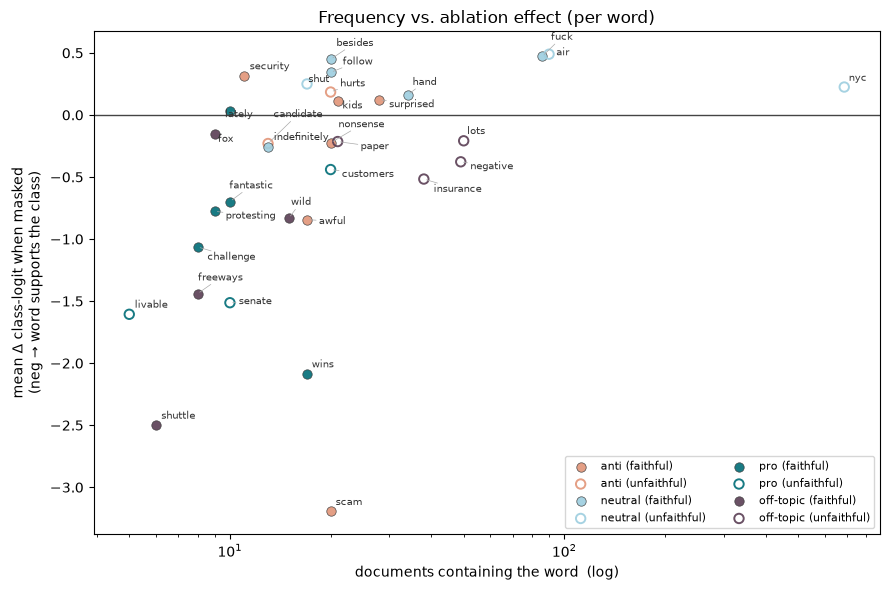

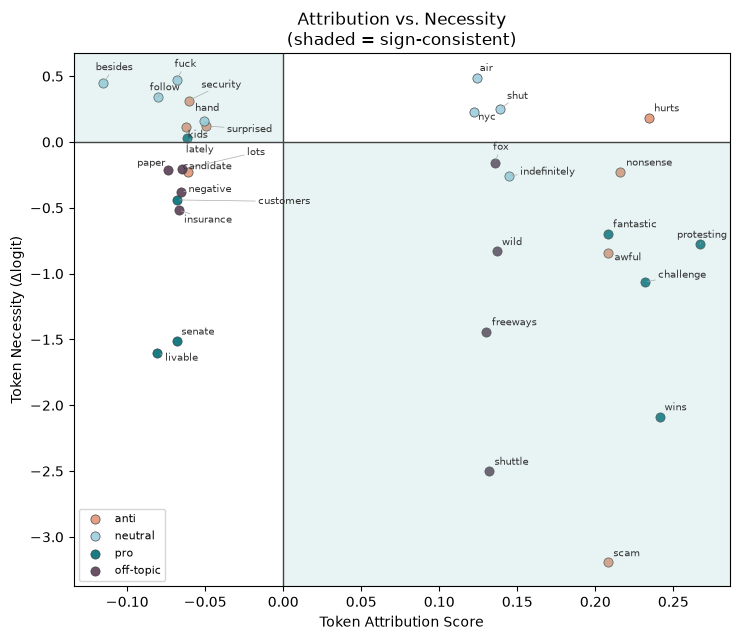

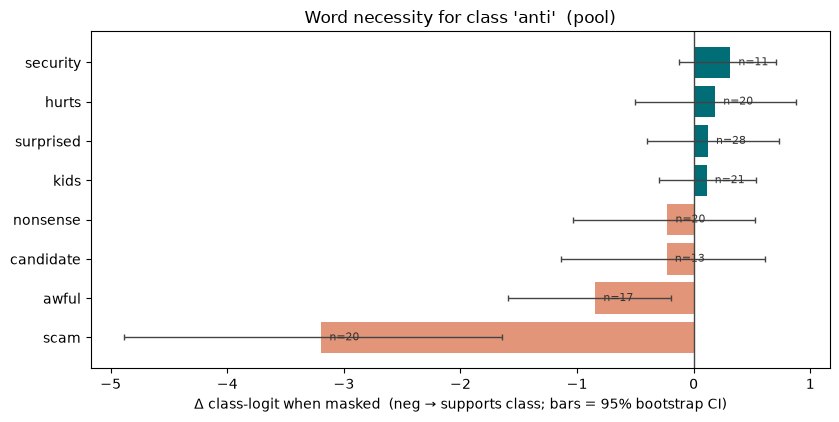

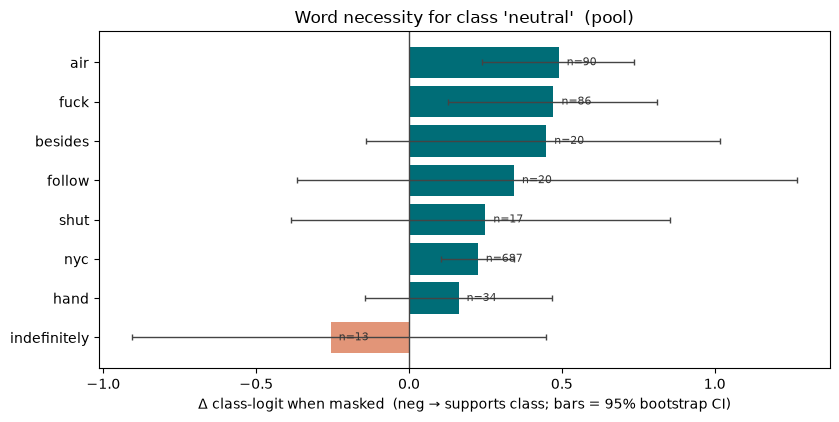

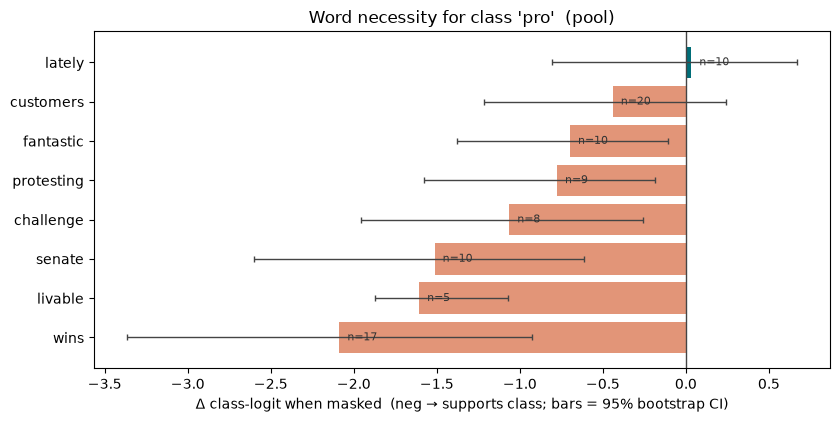

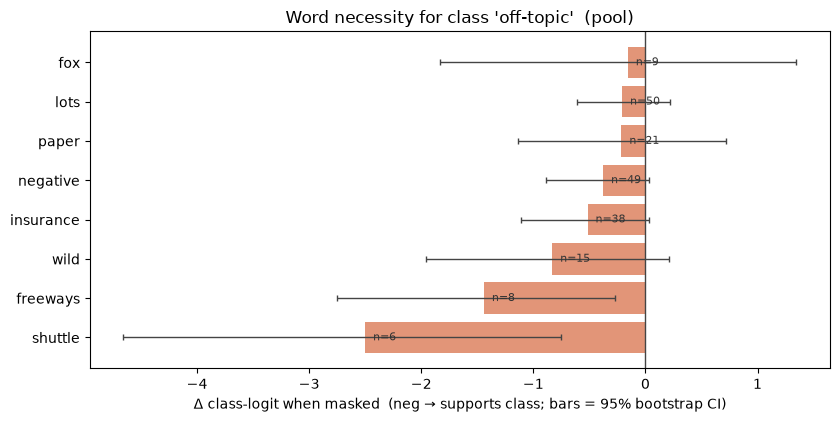

In [10]:
plot_freq_vs_effect(results)
plot_attr_vs_ablation(results)
for c in CLASS_ORDER:
    plot_class_bars(results, c)
print("figures + results written to", OUTPUT_DIR)

'outputs_token_ablation\\attr_vs_ablation_pool.png'

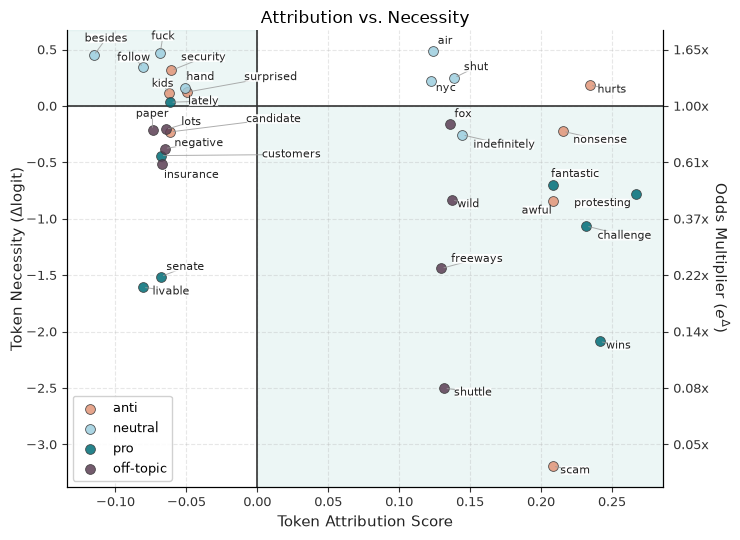

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from adjustText import adjust_text

def plot_attr_vs_ablation4(df, f1=7.5, f2=5.5, name="attr_vs_ablation.png"):
    """Faithfulness: attribution vs measured Δlogit. Faithful words sit upper-left / lower-right."""
    fig, ax = plt.subplots(figsize=(f1, f2)) 
    
    for c in CLASS_ORDER:
        d = df[df["class"] == c]
        if d.empty:
            continue
        ax.scatter(d["mean_attr"], d["mean_dlogit"], s=50, color=_CLASS_COLORS[c],
                   label=c, alpha=0.85, edgecolors=EDGE, linewidths=0.6, zorder=3)
                   
    ax.axhline(0, color="#333", lw=1.2, zorder=2)
    ax.axvline(0, color="#333", lw=1.2, zorder=2)
    ax.grid(True, linestyle="--", alpha=0.3, zorder=1)
    
    xl, yl = ax.get_xlim(), ax.get_ylim()
    ax.fill_between([0, xl[1]], 0, yl[0], color=FAITHFUL_WASH, alpha=0.15, zorder=0) 
    ax.fill_between([xl[0], 0], 0, yl[1], color=FAITHFUL_WASH, alpha=0.15, zorder=0) 
    ax.set_xlim(xl); ax.set_ylim(yl)
    
    ax.set_xlabel("Token Attribution Score", fontsize=11, color="#222")
    ax.set_ylabel(r"Token Necessity ($\Delta$logit)", fontsize=11, color="#222", labelpad=0)
    ax.set_title("Attribution vs. Necessity", fontsize=12, pad=5)
    ax.legend(fontsize=9, loc='lower left', framealpha=0.9, edgecolor="#CCC")

    ax2 = ax.twinx()
    ax2.set_ylim(yl)
    valid_ticks = [t for t in ax.get_yticks() if yl[0] <= t <= yl[1]]
    ax2.set_yticks(valid_ticks)
    ax2.set_yticklabels([f"{np.exp(t):.2f}x" for t in valid_ticks])
    ax2.set_ylabel(r"Odds Multiplier ($e^{\Delta}$)", fontsize=11, color="#222", rotation=270, labelpad=15)
    
    ax.tick_params(axis='both', labelsize=9, colors="#333")
    ax2.tick_params(axis='y', labelsize=9, colors="#333")
    
    texts = []
    bbox_props = dict(boxstyle="round,pad=-0.1", facecolor="white", edgecolor="none", alpha=0.95)
    
    for i, row in df.iterrows():
        texts.append(
            ax.text(row["mean_attr"], row["mean_dlogit"], row["token"], 
                    fontsize=8, color="#222", ha='left', va='center', 
                    bbox=bbox_props, zorder=4) 
        )

    # CORRECTED: Let the algorithm resolve the overlap natively.
    # expand_points acts as a buffer to ensure text clears the physical size of the dots.
    adjust_text(texts, ax=ax, 
                expand=(1.45, 1.45), 
                force_points=(1.1, 1.1),
                arrowprops=dict(arrowstyle='-', color='#999', lw=0.7, zorder=2, alpha=0.8))

    ax.spines["top"].set_visible(False)
    ax2.spines["top"].set_visible(False)
    
    fig.tight_layout()
    return _save(fig, name)

plot_attr_vs_ablation4(results)

'outputs_token_ablation\\attr_vs_ablation_pool.png'

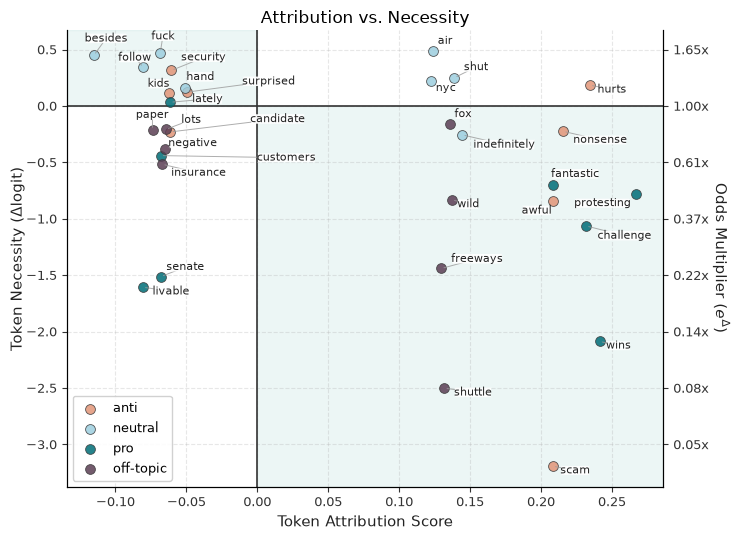

In [20]:
plot_attr_vs_ablation4(results, f1=7.5, f2=5.5)